# Feature Engineering


In [102]:
import numpy as np
import pandas as pd
import yfinance as yf
from market_ml.data_loader import DataLoader
import matplotlib.pyplot as plt
import plotly.express as px
from market_ml.config import * 
from market_ml.EDA import * 
from market_ml.feature_engineering import *
from market_ml.models import *

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


# Data Loading 


In [103]:
stock_dl = DataLoader(tickers=TICKERS, period="10y", interval="1d", file_name='stock_data.parquet')
benchmark_dl = DataLoader(tickers=[BENCHMARK_TICKERS], period="10y", interval="1d", file_name='benchmark_data.parquet')

market_data = stock_dl.load_data()
benchmark_data = benchmark_dl.load_data()
sectors = market_data["Sector"].unique()

benchmark_data

Data loaded for ['AAPL', 'MSFT', 'NVDA', 'META', 'GOOGL', 'JPM', 'GS', 'BAC', 'MS', 'BLK', 'JNJ', 'UNH', 'ABBV', 'PFE', 'MRK', 'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'AMZN', 'COST', 'WMT', 'HD', 'MCD']
Data loaded for [['SPY', 'QQQ']]


Price,Date,Ticker,Sector,Close,High,Low,Open,Volume
0,2016-09-29,QQQ,NaN,110.121559,110.943924,109.644969,110.738333,27207500
1,2016-09-29,SPY,NaN,183.335754,185.206007,182.789198,184.804628,128070600
2,2016-09-30,QQQ,NaN,110.943939,111.271013,110.299131,110.411274,25543200
3,2016-09-30,SPY,NaN,184.719223,185.419493,183.916465,184.164118,117202900
4,2016-10-03,QQQ,NaN,110.785042,110.925211,110.355165,110.803729,19216400
...,...,...,...,...,...,...,...,...
5021,2026-09-25,SPY,NaN,771.349976,772.280029,766.289978,768.780029,36666700
5022,2026-09-28,QQQ,NaN,736.530029,741.419983,731.630005,740.460022,41716200
5023,2026-09-28,SPY,NaN,765.609985,769.539978,763.719971,768.349976,42296700
5024,2026-09-29,QQQ,NaN,737.229980,740.579895,736.000000,740.169983,9703756


In [104]:
#just testing with one stock for now 

test_ticker = ['AAPL', 'NVDA']
test_data = market_data[market_data["Ticker"].isin(test_ticker)].copy()

test_data

Price,Date,Ticker,Sector,Close,High,Low,Open,Volume
0,2016-09-29,AAPL,Technology,25.653965,26.024437,25.567065,25.878078,143548000
19,2016-09-29,NVDA,Technology,1.653514,1.658666,1.620394,1.635605,336684000
25,2016-09-30,AAPL,Technology,25.852909,25.926088,25.567052,25.717984,145516400
44,2016-09-30,NVDA,Technology,1.680990,1.697427,1.652778,1.662591,429932000
50,2016-10-03,AAPL,Technology,25.731701,25.852906,25.676817,25.775152,86807200
...,...,...,...,...,...,...,...,...
62769,2026-09-25,NVDA,Technology,225.070007,226.940002,223.130005,225.130005,89947700
62775,2026-09-28,AAPL,Technology,338.399994,342.989990,338.040009,340.369995,32724700
62794,2026-09-28,NVDA,Technology,228.860001,233.210007,228.039993,229.750000,141544300
62800,2026-09-29,AAPL,Technology,332.345001,337.059998,331.510010,337.059998,12025955


In [105]:
engineer = FeatureEngineer(test_data, benchmark_data, filename="test_stock_data_with_features.parquet")
data  = engineer.load_features()

data.shape

Data loaded for Price       Date Ticker      Sector       Close        High         Low  \
0     2016-09-29   AAPL  Technology   25.653965   26.024437   25.567065   
19    2016-09-29   NVDA  Technology    1.653514    1.658666    1.620394   
25    2016-09-30   AAPL  Technology   25.852909   25.926088   25.567052   
44    2016-09-30   NVDA  Technology    1.680990    1.697427    1.652778   
50    2016-10-03   AAPL  Technology   25.731701   25.852906   25.676817   
...          ...    ...         ...         ...         ...         ...   
62769 2026-09-25   NVDA  Technology  225.070007  226.940002  223.130005   
62775 2026-09-28   AAPL  Technology  338.399994  342.989990  338.040009   
62794 2026-09-28   NVDA  Technology  228.860001  233.210007  228.039993   
62800 2026-09-29   AAPL  Technology  332.345001  337.059998  331.510010   
62819 2026-09-29   NVDA  Technology  230.899994  232.820007  229.220001   

Price        Open     Volume  
0       25.878078  143548000  
19       1.635605  33

(4908, 21)

In [106]:
print(data.shape)

print(data[["Date", "Ticker"]].head())

print(data.sort_values(["Date", "Ticker"]).reset_index(drop=True))



(4908, 21)
Price       Date Ticker
98    2016-12-08   AAPL
99    2016-12-08   NVDA
100   2016-12-09   AAPL
101   2016-12-09   NVDA
102   2016-12-12   AAPL
Price       Date Ticker      Sector       Close        High         Low  \
0     2016-12-08   AAPL  Technology   25.771877   25.843133   25.422489   
1     2016-12-08   NVDA  Technology    2.296763    2.373912    2.286199   
2     2016-12-09   AAPL  Technology   26.192514   26.364909   25.815545   
3     2016-12-09   NVDA  Technology    2.255978    2.316174    2.228706   
4     2016-12-12   AAPL  Technology   26.043110   26.433871   25.856922   
...          ...    ...         ...         ...         ...         ...   
4903  2026-09-11   NVDA  Technology  218.289993  222.000000  218.149994   
4904  2026-09-14   AAPL  Technology  333.079987  335.500000  331.339996   
4905  2026-09-14   NVDA  Technology  210.960007  212.770004  208.929993   
4906  2026-09-15   AAPL  Technology  331.339996  331.779999  328.350006   
4907  2026-09-15   N

In [107]:
print("Start:", data["Date"].min())
print("End:  ", data["Date"].max())

Start: 2016-12-08 00:00:00
End:   2026-09-15 00:00:00


# Splitting Data into Train and Test 

In [108]:
train_data, test_data, split_date = split_chronological_data(data)



In [109]:
features = list(train_data.columns)[:-1]
target = list(train_data)[-1]
features = ["QQQ_Return","SPY_Return","Daily_Return","Return_5D","Volatility_20D","Price_to_SMA_20D","Price_to_SMA_50D","Relative_Volume_20D",
] #want to remove everything with future information

In [110]:
x_train, y_train = train_data[features], train_data[target]
x_test, y_test = test_data[features], test_data[target]

x_test.columns

Index(['QQQ_Return', 'SPY_Return', 'Daily_Return', 'Return_5D',
       'Volatility_20D', 'Price_to_SMA_20D', 'Price_to_SMA_50D',
       'Relative_Volume_20D'],
      dtype='str', name='Price')

# Logistic Regression

As I'm using logistic regression and some of the features may have larger values than others, I'm going to use a standard scaler.  

In [111]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

logModel = LogisticRegression()

logModel.fit(x_train_scaled, y_train)

y_pred = logModel.predict(x_test_scaled)

In [112]:
y_prob = logModel.predict_proba(x_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

cr = classification_report(y_test, y_pred) 

cm = confusion_matrix(y_test, y_pred) 

roc_auc = roc_auc_score(y_test, y_prob)

/Users/Aoife/python/market_ml_research/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [113]:
print(cr)

              precision    recall  f1-score   support

         0.0       0.33      0.00      0.00       425
         1.0       0.57      1.00      0.72       557

    accuracy                           0.57       982
   macro avg       0.45      0.50      0.36       982
weighted avg       0.47      0.57      0.41       982



Recall looks overfit - something else must be going on here. Low accuracy and precision too. 

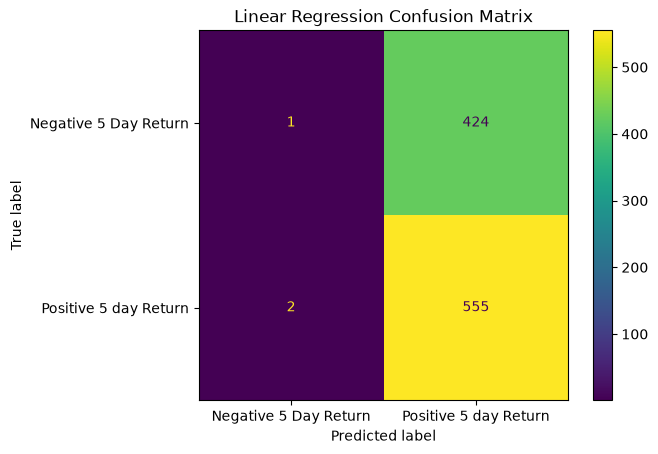

In [114]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Negative 5 Day Return', 'Positive 5 day Return'])

cm_display.plot()
plt.title("Linear Regression Confusion Matrix")
plt.show()

In [115]:
y_test.value_counts(normalize=True)

Target_5D
1.0    0.56721
0.0    0.43279
Name: proportion, dtype: float64

Only 3 0.0 predictions. 

In [116]:
print(f"ROC-AUC is {np.round(roc_auc, 2)}")

ROC-AUC is 0.47


ROC-AUC of 0.5 is a random model (ie if the target was chosen randomly). The ROC-AUC score here shows that this linear regression model is close to random (not good). Which shows that the linear regression model shows that the features cannot distinguish whether the 5day return will be positive or negative. This is a starting point and a baseline model for now. 

# Hyperparameter Tuning for Logistic Regression 

In [117]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

logModel = LogisticRegression(random_state=42)

cv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "C":[0.01, 0.1, 1.0, 10, 100 ], 
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(logModel,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)



In [118]:
grid_search.fit(x_train_scaled, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)



{'C': 0.01, 'class_weight': None}
0.4891870333515653


In [119]:
best_parameters = list(grid_search.best_params_.values())

logModel = LogisticRegression(C=best_parameters[0], class_weight=best_parameters[1], random_state=42)

logModel.fit(x_train_scaled, y_train)
logModel.predict(x_test_scaled)



array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [120]:
y_prob = logModel.predict_proba(x_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

cr = classification_report(y_test, y_pred) 

cm = confusion_matrix(y_test, y_pred) 

roc_auc = roc_auc_score(y_test, y_prob)

In [121]:
print(cr)

              precision    recall  f1-score   support

         0.0       0.33      0.00      0.00       425
         1.0       0.57      1.00      0.72       557

    accuracy                           0.57       982
   macro avg       0.45      0.50      0.36       982
weighted avg       0.47      0.57      0.41       982



In [122]:
print(f"Accuracy is {np.round(accuracy,2)}")
print(f"ROC-AUC is {np.round(roc_auc, 2)}")

Accuracy is 0.57
ROC-AUC is 0.49


Minimal improvement with hyperparameter tuning

In [123]:
baseline_results = {"Model": "Linear_Regression", 
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "ROC_AUC": roc_auc_score(y_test, y_prob)}

# Random Forest

In [124]:
ntrees = 100
max_depth = 5 #default is None which I don't want to use at it'll overfit
random_state = 42 #for reproducability 
njobs = -1 #allowing it to use all available cores on my computer 
rf_model = RandomForestClassifier(n_estimators=ntrees, max_depth=max_depth, random_state=random_state, n_jobs=njobs)

In [125]:
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)[:, 1]


In [126]:
y_prob = rf_model.predict_proba(x_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

cr = classification_report(y_test, y_pred) 

cm = confusion_matrix(y_test, y_pred) 

roc_auc = roc_auc_score(y_test, y_prob)

In [127]:
print(f"Accuracy {np.round(accuracy,2)}")
print(f"ROC-AUC is {np.round(roc_auc, 2)}")

Accuracy 0.57
ROC-AUC is 0.47


In [128]:
print(cr)

              precision    recall  f1-score   support

         0.0       0.42      0.01      0.02       425
         1.0       0.57      0.99      0.72       557

    accuracy                           0.57       982
   macro avg       0.49      0.50      0.37       982
weighted avg       0.50      0.57      0.42       982



Some improvements on the recall but still results are not great. 

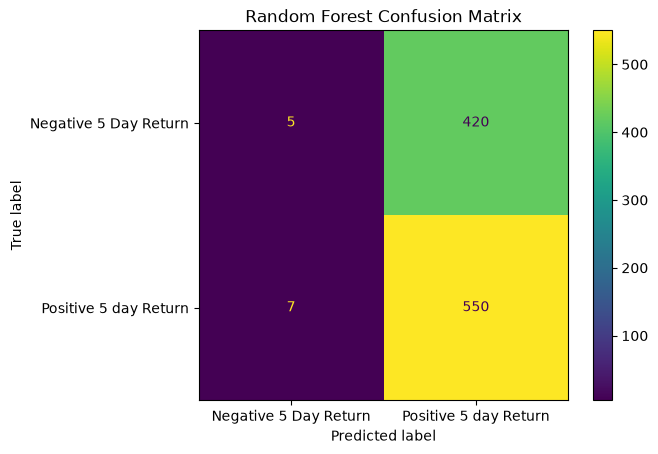

In [129]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Negative 5 Day Return', 'Positive 5 day Return'])

cm_display.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

Same ROC-AUC as linear regression. 

# Random Forest Hyperparameter Tuning

In [136]:
rf_Model = RandomForestClassifier(random_state=42)

cv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators":[50, 100, 200, 300, 400],
    "max_depth": [3, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5],
}

grid_search = GridSearchCV(rf_Model,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)



In [137]:
grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 50}
0.49890985930918985


In [138]:
best_parameters = grid_search.best_params_

rf_Model = RandomForestClassifier(n_estimators=best_parameters["max_depth"], max_depth=best_parameters["max_depth"], min_samples_leaf=best_parameters["min_samples_leaf"], random_state=42)

rf_Model.fit(x_train, y_train)
rf_Model.predict(x_test)




array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [139]:
y_prob = rf_model.predict_proba(x_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

cr = classification_report(y_test, y_pred) 

cm = confusion_matrix(y_test, y_pred) 

roc_auc = roc_auc_score(y_test, y_prob)

In [140]:
print(f"Accuracy {np.round(accuracy,2)}")
print(f"ROC-AUC is {np.round(roc_auc, 2)}")

Accuracy 0.57
ROC-AUC is 0.47


In [141]:
print(cr)

              precision    recall  f1-score   support

         0.0       0.42      0.01      0.02       425
         1.0       0.57      0.99      0.72       557

    accuracy                           0.57       982
   macro avg       0.49      0.50      0.37       982
weighted avg       0.50      0.57      0.42       982



Random forest has minimal improvement compared to logistic regression. Either something is wrong with the data prep or something else is going on here -- need to investigate further, use regression not classifier. 